Imports

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp
from IPython.display import FileLink
import subprocess

In [ ]:
subprocess.run(['apt-get', 'install', '-y', 'ffmpeg'], capture_output=True)
matplotlib.rcParams['animation.ffmpeg_path'] = '/usr/bin/ffmpeg'

print("All libraries loaded")

All libraries loaded


Parameters & Initial Conditions

In [ ]:
# physical parameters

g  = 9.81   # gravitational acceleration (m/s²)
m1 = 1.0    # mass of bob 1 (kg)
m2 = 1.0    # mass of bob 2 (kg)
L1 = 1.0    # length of rod 1 (m)
L2 = 1.0    # length of rod 2 (m)

In [ ]:
# simulation time

t_end  = 30          # seconds (duration of animation)
dt     = 0.005       # time step (smaller = more accurate)
t_eval = np.arange(0, t_end, dt)

In [ ]:
# Large angles (> 90°) produce chaotic motion
# Small angles (< 20°) produce regular periodic motion

th1_0 = np.radians(110)   # starting angle of bob 1
th2_0 = np.radians(110)   # starting angle of bob 2
w1_0  = 0.0               # starting angular velocity of bob 1
w2_0  = 0.0               # starting angular velocity of bob 2

In [ ]:
# State vector: [theta1, omega1, theta2, omega2]

y0          = [th1_0,        w1_0, th2_0, w2_0]
y0_perturb  = [th1_0 + 1e-5, w1_0, th2_0, w2_0]   # tiny nudge for chaos demo

In [ ]:
print(f"  θ₁ = {np.degrees(th1_0):.0f}°,  θ₂ = {np.degrees(th2_0):.0f}°")
print(f"  Duration: {t_end}s  |  Steps: {len(t_eval):,}")

  θ₁ = 110°,  θ₂ = 110°
  Duration: 30s  |  Steps: 6,000


Equations of Motion

In [ ]:
def derivs(t, y):
    th1, w1, th2, w2 = y
    dth = th1 - th2

    denom = 2*m1 + m2 - m2*np.cos(2*dth)

    dw1 = (
        -g*(2*m1 + m2)*np.sin(th1)
        - m2*g*np.sin(th1 - 2*th2)
        - 2*np.sin(dth)*m2*(w2**2*L2 + w1**2*L1*np.cos(dth))
    ) / (L1 * denom)

    dw2 = (
        2*np.sin(dth)*(
            w1**2*L1*(m1 + m2)
            + g*(m1 + m2)*np.cos(th1)
            + w2**2*L2*m2*np.cos(dth)
        )
    ) / (L2 * denom)

    return [w1, dw1, w2, dw2]

Solving ODEs

In [ ]:
sol  = solve_ivp(derivs, (0, t_end), y0,
                 method='DOP853', t_eval=t_eval,
                 rtol=1e-10, atol=1e-12)

solp = solve_ivp(derivs, (0, t_end), y0_perturb,
                 method='DOP853', t_eval=t_eval,
                 rtol=1e-10, atol=1e-12)

th1, w1, th2, w2    = sol.y
th1p, w1p, th2p, w2p = solp.y

# Convert angles to Cartesian coordinates
# Pivot is at origin (0, 0); Y increases upward
x1 =  L1 * np.sin(th1)
y1 = -L1 * np.cos(th1)
x2 =  x1 + L2 * np.sin(th2)
y2 =  y1 - L2 * np.cos(th2)

# Perturbed trajectory (bob 2 only, for chaos plot)
x2p =  L1*np.sin(th1p) + L2*np.sin(th2p)
y2p = -L1*np.cos(th1p) - L2*np.cos(th2p)

Plot: Bob 2 Trajectory

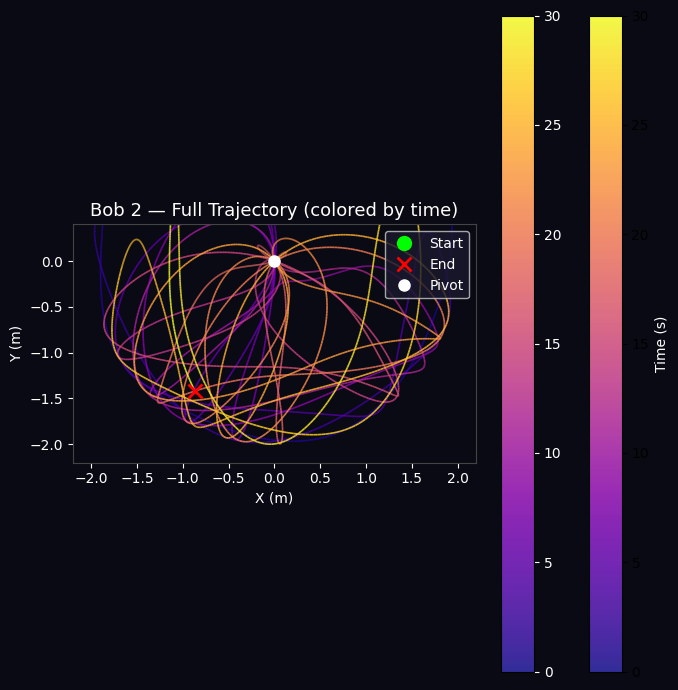

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0a0a14')
ax.set_facecolor('#0a0a14')

# Color the path by time
points = np.array([x2, y2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

from matplotlib.collections import LineCollection
lc = LineCollection(segments, cmap='plasma',
                    norm=plt.Normalize(0, t_end), linewidth=1.2, alpha=0.85)
lc.set_array(t_eval[:-1])
ax.add_collection(lc)
plt.colorbar(lc, ax=ax, label='Time (s)', pad=0.02).ax.yaxis.label.set_color('white')
plt.colorbar(lc, ax=ax).ax.tick_params(colors='white')

ax.plot(x2[0],  y2[0],  'o', color='lime',   ms=10, label='Start', zorder=5)
ax.plot(x2[-1], y2[-1], 'x', color='red',    ms=10, label='End',   zorder=5, mew=2)
ax.plot(0, 0, 'o', color='white', ms=8, label='Pivot', zorder=5)

ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 0.4)
ax.set_xlabel('X (m)', color='white')
ax.set_ylabel('Y (m)', color='white')
ax.set_title('Bob 2 — Full Trajectory (colored by time)', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.set_aspect('equal')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
legend = ax.legend(facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig('trajectory.png', dpi=150, bbox_inches='tight', facecolor='#0a0a14')
plt.show()

Plot: Butterfly Effect (Chaos Demo)

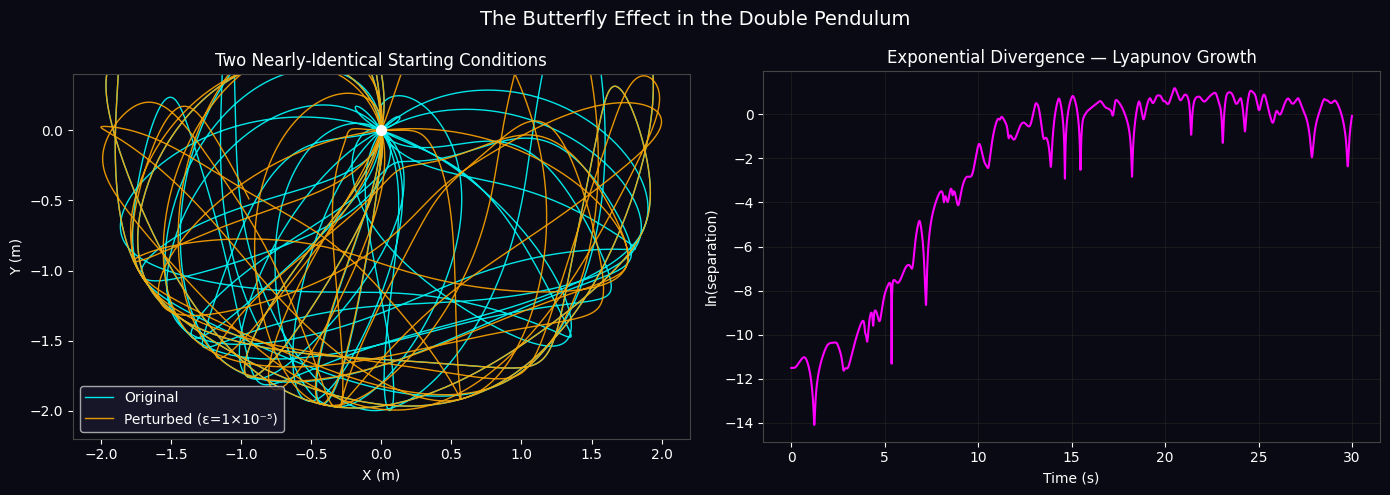

In [ ]:
separation  = np.sqrt((x2 - x2p)**2 + (y2 - y2p)**2)
log_sep     = np.log(separation + 1e-15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0a0a14')

for ax in axes:
    ax.set_facecolor('#0a0a14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

# Left: two trajectories on same plot
axes[0].plot(x2,  y2,  color='cyan',   lw=1.0, alpha=0.9, label='Original')
axes[0].plot(x2p, y2p, color='orange', lw=1.0, alpha=0.9, label=f'Perturbed (ε=1×10⁻⁵)')
axes[0].plot(0, 0, 'o', color='white', ms=7)
axes[0].set_xlim(-2.2, 2.2)
axes[0].set_ylim(-2.2, 0.4)
axes[0].set_xlabel('X (m)', color='white')
axes[0].set_ylabel('Y (m)', color='white')
axes[0].set_title('Two Nearly-Identical Starting Conditions', color='white', fontsize=12)
axes[0].set_aspect('equal')
legend = axes[0].legend(facecolor='#1a1a2e', labelcolor='white')

# Right: log separation over time
axes[1].plot(t_eval, log_sep, color='magenta', lw=1.5)
axes[1].set_xlabel('Time (s)', color='white')
axes[1].set_ylabel('ln(separation)', color='white')
axes[1].set_title('Exponential Divergence — Lyapunov Growth', color='white', fontsize=12)
axes[1].grid(True, color='#222', linewidth=0.5)

plt.suptitle('The Butterfly Effect in the Double Pendulum', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('butterfly_effect.png', dpi=150, bbox_inches='tight', facecolor='#0a0a14')
plt.show()

Plot: Phase Space & Angle over Time

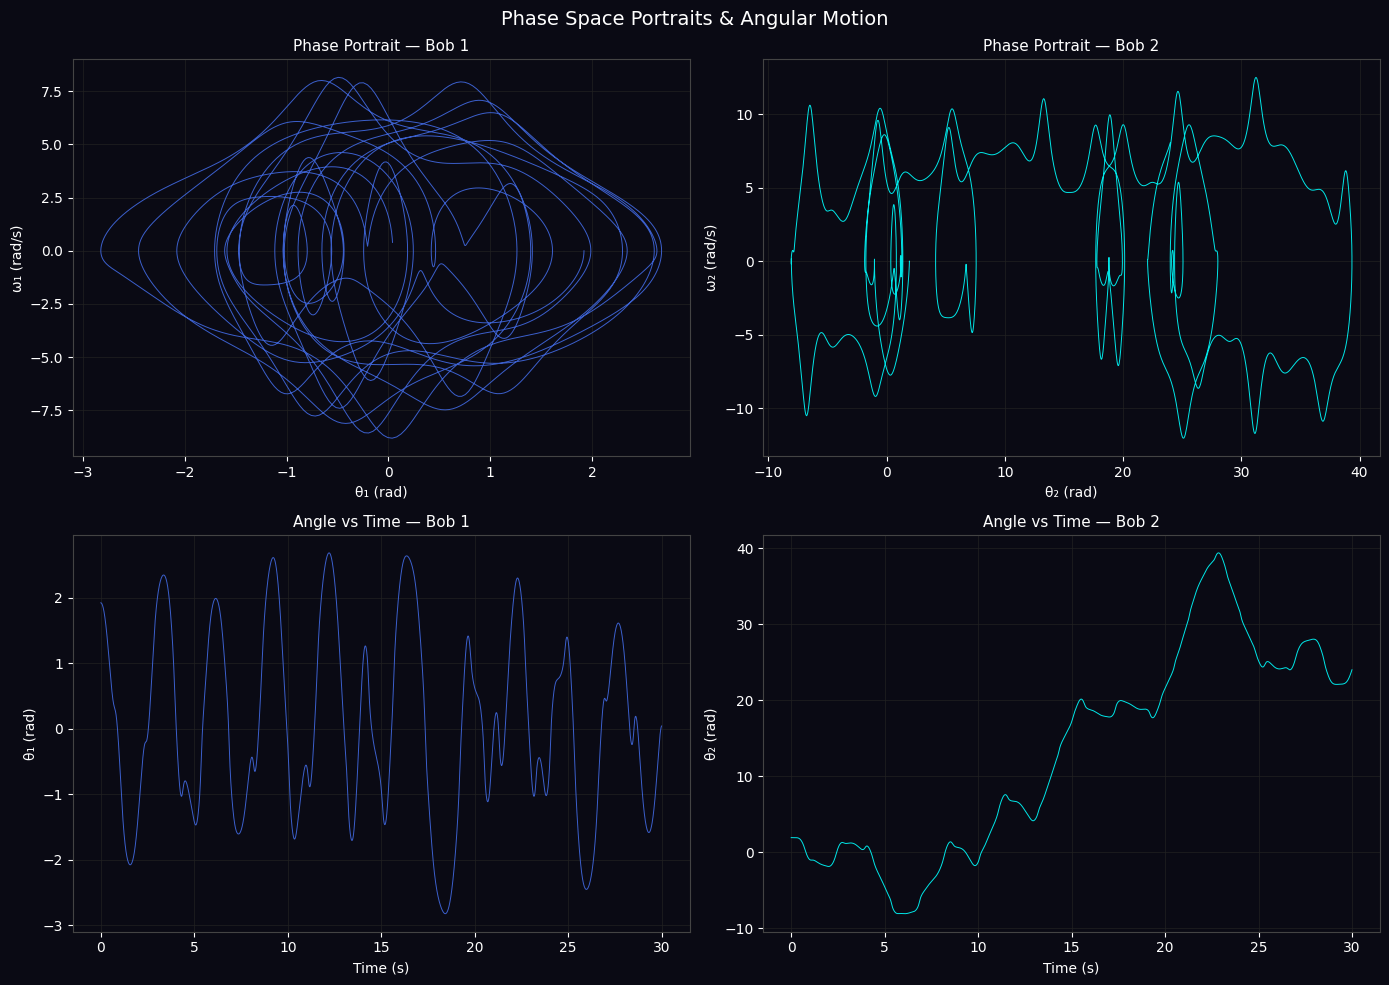

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0a0a14')

plot_configs = [
    (axes[0,0], th1,  w1,  'θ₁ (rad)', 'ω₁ (rad/s)', 'Phase Portrait — Bob 1', 'royalblue'),
    (axes[0,1], th2,  w2,  'θ₂ (rad)', 'ω₂ (rad/s)', 'Phase Portrait — Bob 2', 'cyan'),
    (axes[1,0], t_eval, th1, 'Time (s)', 'θ₁ (rad)',   'Angle vs Time — Bob 1',  'royalblue'),
    (axes[1,1], t_eval, th2, 'Time (s)', 'θ₂ (rad)',   'Angle vs Time — Bob 2',  'cyan'),
]

for ax, xdata, ydata, xlabel, ylabel, title, color in plot_configs:
    ax.set_facecolor('#0a0a14')
    ax.plot(xdata, ydata, color=color, lw=0.7, alpha=0.9)
    ax.set_xlabel(xlabel, color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.set_title(title, color='white', fontsize=11)
    ax.tick_params(colors='white')
    ax.grid(True, color='#222', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.suptitle('Phase Space Portraits & Angular Motion', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('phase_space.png', dpi=150, bbox_inches='tight', facecolor='#0a0a14')
plt.show()

Plot: Energy Conservation (Error Analysis)

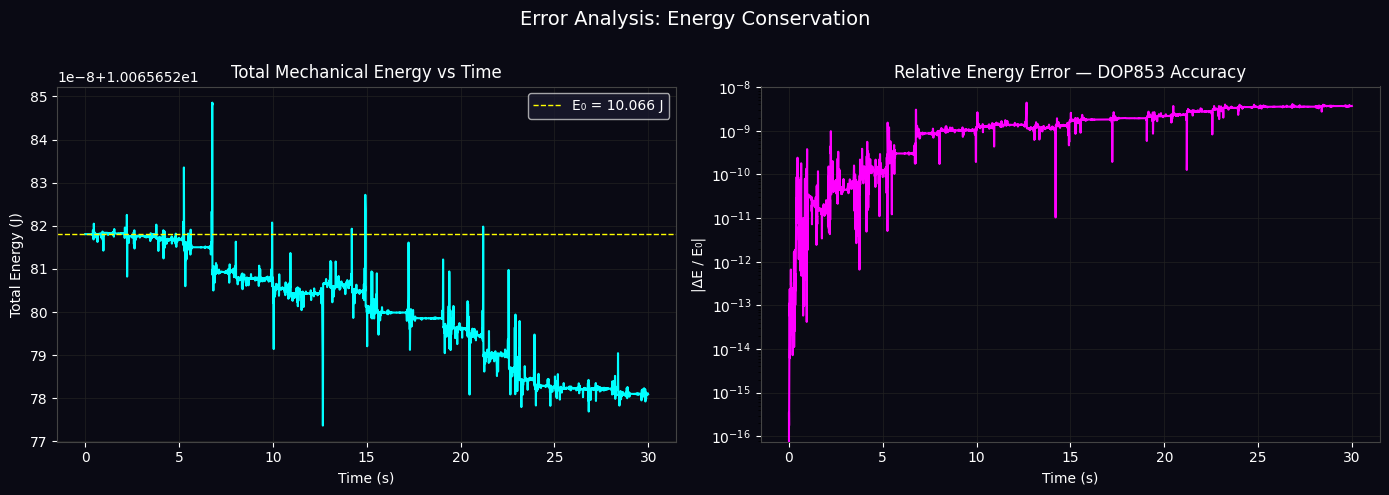

Max relative energy error: 4.41e-09


In [ ]:
def total_energy(th1, w1, th2, w2):
    # Kinetic energy
    T1 = 0.5 * m1 * (L1 * w1)**2
    T2 = 0.5 * m2 * (
        (L1*w1*np.cos(th1) + L2*w2*np.cos(th2))**2 +
        (L1*w1*np.sin(th1) + L2*w2*np.sin(th2))**2
    )
    # Potential energy (pivot at origin, y downward is negative)
    V1 = -m1 * g * L1 * np.cos(th1)
    V2 = -m2 * g * (L1*np.cos(th1) + L2*np.cos(th2))
    return T1 + T2 + V1 + V2

E  = total_energy(th1, w1, th2, w2)
E0 = E[0]
rel_err = np.abs((E - E0) / E0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0a0a14')

for ax in axes:
    ax.set_facecolor('#0a0a14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

axes[0].plot(t_eval, E, color='cyan', lw=1.5)
axes[0].axhline(E0, color='yellow', lw=1, linestyle='--', label=f'E₀ = {E0:.3f} J')
axes[0].set_xlabel('Time (s)', color='white')
axes[0].set_ylabel('Total Energy (J)', color='white')
axes[0].set_title('Total Mechanical Energy vs Time', color='white', fontsize=12)
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0].grid(True, color='#222', linewidth=0.5)

axes[1].semilogy(t_eval, rel_err, color='magenta', lw=1.5)
axes[1].set_xlabel('Time (s)', color='white')
axes[1].set_ylabel('|ΔE / E₀|', color='white')
axes[1].set_title('Relative Energy Error — DOP853 Accuracy', color='white', fontsize=12)
axes[1].grid(True, color='#222', linewidth=0.5)

plt.suptitle('Error Analysis: Energy Conservation', color='white', fontsize=14)
plt.tight_layout()
plt.savefig('energy_conservation.png', dpi=150, bbox_inches='tight', facecolor='#0a0a14')
plt.show()
print(f"Max relative energy error: {rel_err.max():.2e}")

Animation (Saves as MP4)

In [ ]:
import matplotlib
import matplotlib.animation as animation
from IPython.display import FileLink
import subprocess

subprocess.run(['apt-get', 'install', '-y', 'ffmpeg'], capture_output=True)
matplotlib.rcParams['animation.ffmpeg_path'] = '/usr/bin/ffmpeg'

print("Building animation (2–5 minutes)...")

step         = 3
trail_length = 400

# Total reach of system = L1 + L2 = 2.0 m from pivot
# Pivot is at (0, 0), so full range is -2.0 to +2.0 in X
# In Y: bobs can go UP to +2.0 and DOWN to -2.0
LIMIT = 2.1

fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0a0a14')
ax.set_facecolor('#0a0a14')
ax.set_xlim(-LIMIT, LIMIT)
ax.set_ylim(-LIMIT, LIMIT)   # ← symmetric: allows bobs to go above pivot too
ax.set_aspect('equal')
ax.set_xlabel('X (m)', color='white')
ax.set_ylabel('Y (m)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.grid(True, color='#1a1a1a', linewidth=0.5)

# Draw a faint circle showing max reach of bob 2
reach_circle = plt.Circle((0, 0), L1+L2, color='#ffffff',
                            fill=False, lw=0.5, alpha=0.15, linestyle='--')
ax.add_patch(reach_circle)

# Pivot marker
ax.plot(0, 0, 's', color='white', ms=8, zorder=10)

title     = ax.set_title('2D Double Pendulum', color='white', fontsize=13)
time_text = ax.text(0.02, 0.96, '', transform=ax.transAxes,
                    color='white', fontsize=11, va='top')

trail1_line, = ax.plot([], [], color='#3355ff', lw=1.0, alpha=0.35)
trail2_line, = ax.plot([], [], color='cyan',    lw=1.8, alpha=0.85)
rod1_line,   = ax.plot([], [], color='#dddddd', lw=2.5, solid_capstyle='round')
rod2_line,   = ax.plot([], [], color='#dddddd', lw=2.5, solid_capstyle='round')
bob1_dot,    = ax.plot([], [], 'o', color='#4488ff', ms=12, zorder=9)
bob2_dot,    = ax.plot([], [], 'o', color='#ff4422', ms=16, zorder=9)

def init():
    for obj in [trail1_line, trail2_line, rod1_line, rod2_line, bob1_dot, bob2_dot]:
        obj.set_data([], [])
    time_text.set_text('')
    return trail1_line, trail2_line, rod1_line, rod2_line, bob1_dot, bob2_dot, time_text

def update(frame):
    i  = min(frame * step, len(t_eval) - 1)
    ts = max(0, i - trail_length)

    trail1_line.set_data(x1[ts:i+1], y1[ts:i+1])
    trail2_line.set_data(x2[ts:i+1], y2[ts:i+1])
    rod1_line.set_data([0, x1[i]],     [0, y1[i]])
    rod2_line.set_data([x1[i], x2[i]], [y1[i], y2[i]])
    bob1_dot.set_data([x1[i]], [y1[i]])
    bob2_dot.set_data([x2[i]], [y2[i]])
    time_text.set_text(f't = {t_eval[i]:.2f} s')

    return trail1_line, trail2_line, rod1_line, rod2_line, bob1_dot, bob2_dot, time_text

n_frames = len(t_eval) // step

ani = animation.FuncAnimation(
    fig, update, frames=n_frames,
    init_func=init, interval=1000/60,
    blit=True
)

writer = animation.FFMpegWriter(fps=60, bitrate=3000,
                                 metadata=dict(title='2D Double Pendulum'))
output_path = 'double_pendulum_2d.mp4'
ani.save(output_path, writer=writer, dpi=130,
         savefig_kwargs={'facecolor': '#0a0a14'})
plt.close()

print(f"Saved: {output_path}")
FileLink(output_path)

Building animation (2–5 minutes)...
Saved: double_pendulum_2d.mp4


/content/double_pendulum_2d.mp4

## Solver Comparison: Euler vs RK4 vs DOP853

To compare performance and accuracy, we implement the lower-order solvers manually since `solve_ivp` primarily focuses on adaptive methods. We will look at **Energy Conservation** as our primary metric for accuracy.

In [ ]:
def euler_step(func, t, y, dt):
    return y + np.array(func(t, y)) * dt

def rk4_step(func, t, y, dt):
    k1 = np.array(func(t, y))
    k2 = np.array(func(t + dt/2, y + dt*k1/2))
    k3 = np.array(func(t + dt/2, y + dt*k2/2))
    k4 = np.array(func(t + dt, y + dt*k3))
    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Arrays to store results
y_euler = np.zeros((len(t_eval), 4))
y_rk4   = np.zeros((len(t_eval), 4))

y_euler[0] = y0
y_rk4[0]   = y0

# Execute fixed-step integration
for i in range(len(t_eval)-1):
    y_euler[i+1] = euler_step(derivs, t_eval[i], y_euler[i], dt)
    y_rk4[i+1]   = rk4_step(derivs, t_eval[i], y_rk4[i], dt)

# Calculate energies for comparison
E_euler  = total_energy(y_euler[:,0], y_euler[:,1], y_euler[:,2], y_euler[:,3])
E_rk4    = total_energy(y_rk4[:,0],   y_rk4[:,1],   y_rk4[:,2],   y_rk4[:,3])
E_dop853 = E  # From our earlier DOP853 run

print("Integration complete.")

Integration complete.


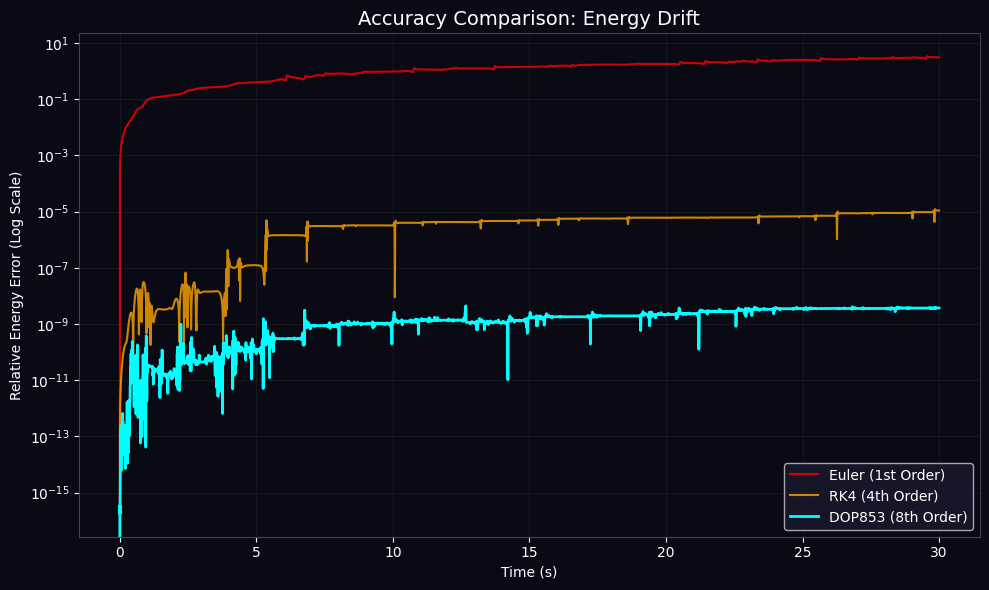

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0a0a14')
ax.set_facecolor('#0a0a14')

# Plot relative error yeah yay
ax.semilogy(t_eval, np.abs((E_euler - E0)/E0), color='red', label='Euler (1st Order)', alpha=0.8)
ax.semilogy(t_eval, np.abs((E_rk4 - E0)/E0), color='orange', label='RK4 (4th Order)', alpha=0.8)
ax.semilogy(t_eval, np.abs((E_dop853 - E0)/E0), color='cyan', label='DOP853 (8th Order)', lw=2)

ax.set_xlabel('Time (s)', color='white')
ax.set_ylabel('Relative Energy Error (Log Scale)', color='white')
ax.set_title('Accuracy Comparison: Energy Drift', color='white', fontsize=14)
ax.tick_params(colors='white')
ax.grid(True, which="both", ls="-", color='#222', alpha=0.5)
ax.legend(facecolor='#1a1a2e', labelcolor='white')

for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

### Observations
1. **Euler (1st Order):** The error grows exponentially and very quickly. In many cases, Euler will cause the pendulum to 'gain energy' artificially until it spins unrealistically fast.
2. **RK4 (4th Order):** A significant improvement. It is suitable for many real-time applications (like games), but over 30 seconds, you can see visible drift in the energy.
3. **DOP853 (8th Order):** The error stays near the machine epsilon/tolerance floor. It is the gold standard for scientific simulations where long-term stability is required.